In [72]:

import numpy as np
import tensorflow
from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras import layers
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, accuracy_score,f1_score

In [73]:
from keras.datasets import mnist

In [74]:
(X_train, Y_train) , (X_test, Y_test) = mnist.load_data()

Tried to load the train/test data without using () but it showed Value Error for some reason

In [75]:
print(X_train.shape, Y_train.shape)
print(X_test.shape, Y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


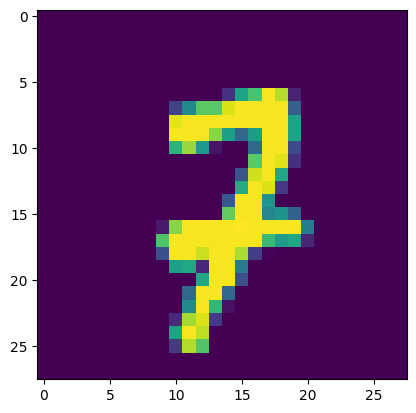

In [78]:
rand_numb = np.random.randint(1,30000)
plt.imshow(X_train[rand_numb])

Does the mnist dataset show only 1-digit numbers? Because I tried to show more numbers

IndexError: index 0 is out of bounds for axis 0 with size 0

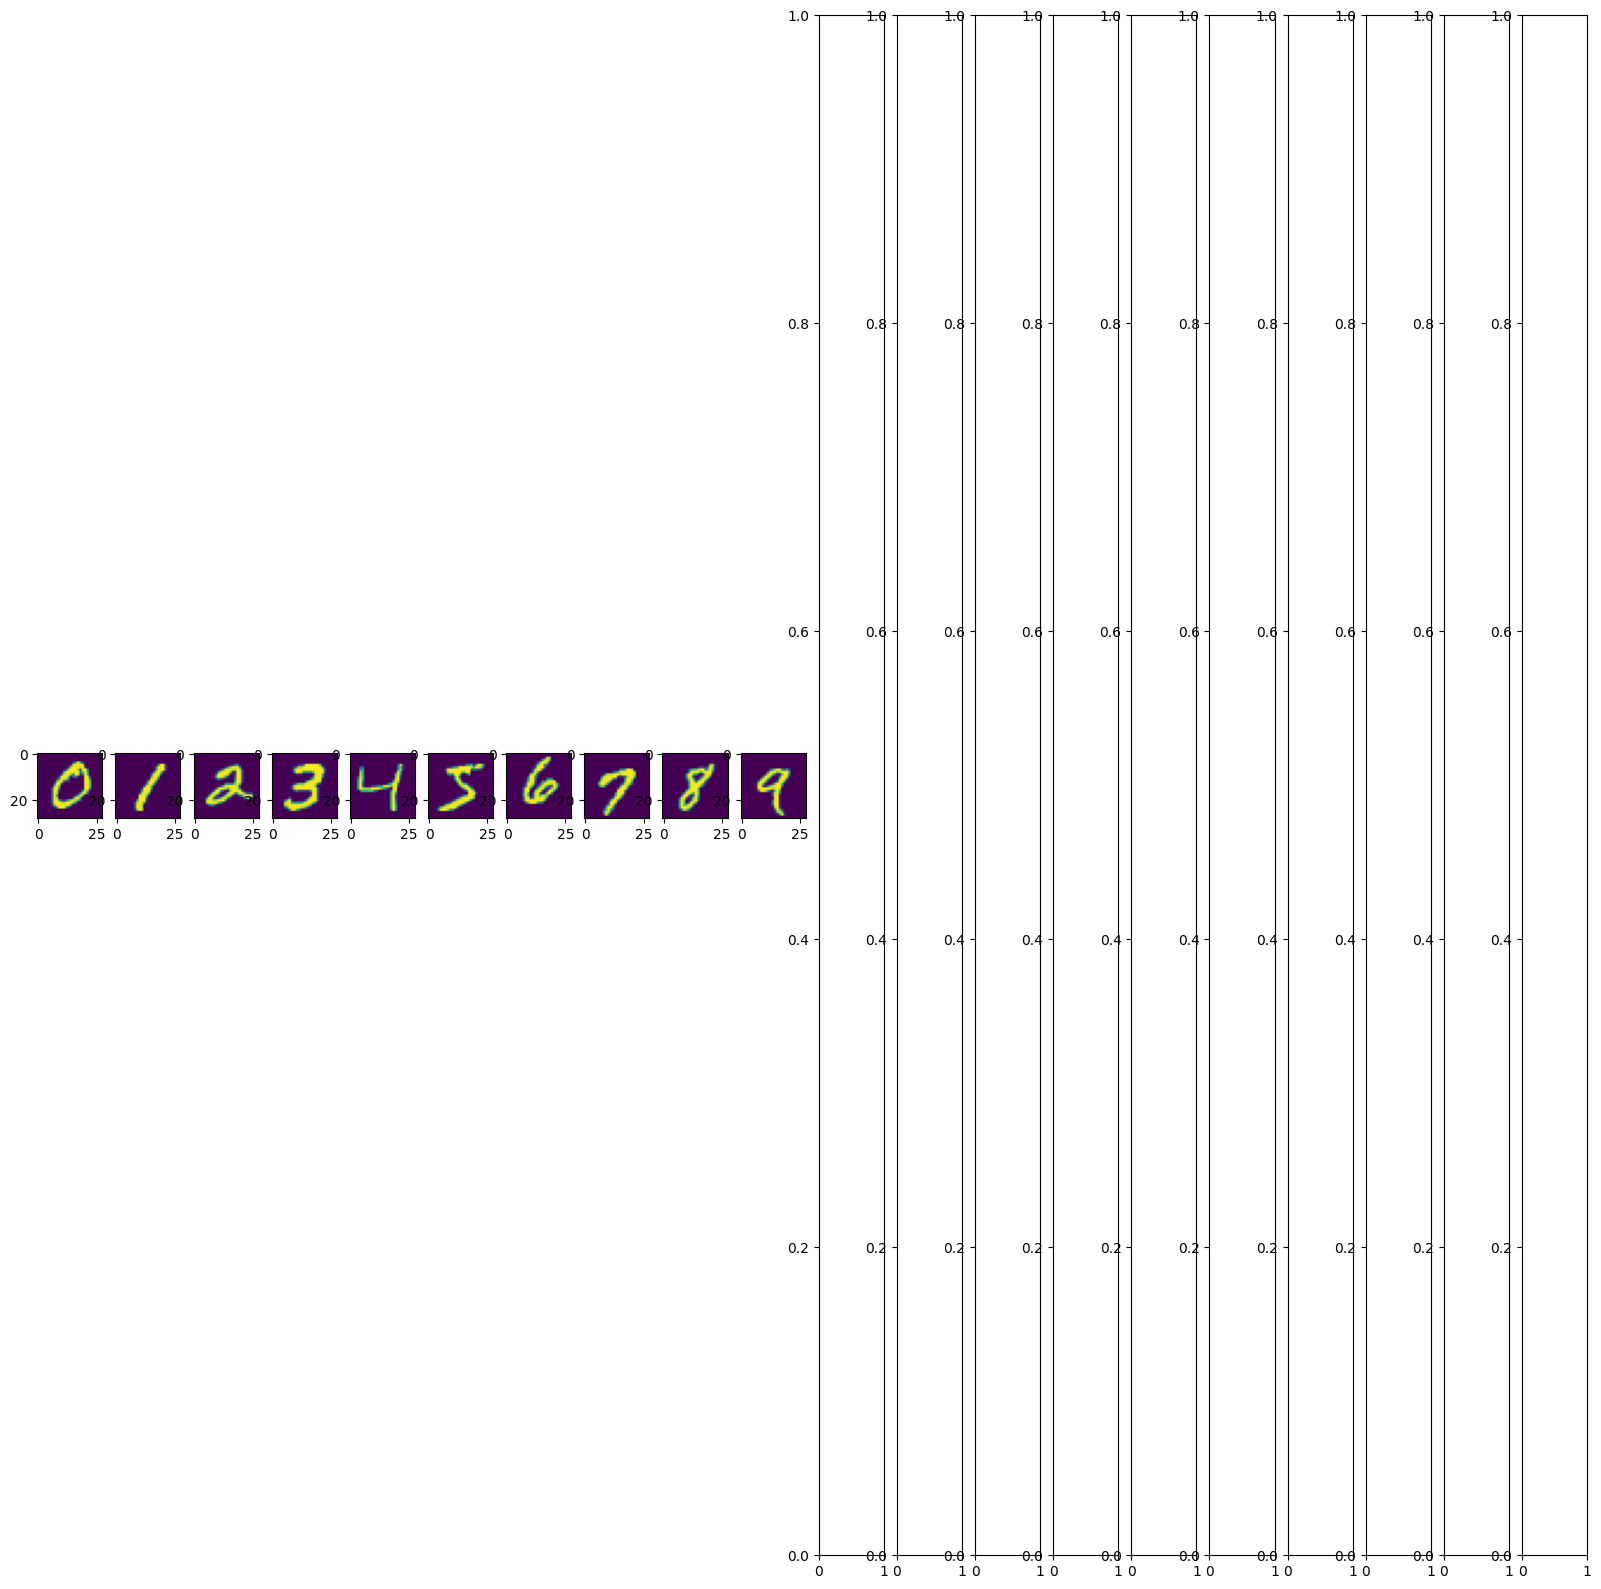

In [79]:
fig, a = plt.subplots(1,20,figsize=(20,20))
for i in range(20):
  sample = X_train[Y_train==i][0]
  a[i].imshow(sample)

In [80]:
Y_train = keras.utils.to_categorical(Y_train,10)
Y_test = keras.utils.to_categorical(Y_test,10)
print(Y_train[1])

[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [81]:
X_train = X_train/255
X_test = X_test/255

In [82]:
X_train.shape

(60000, 28, 28)

In [83]:
X_train = X_train.reshape(X_train.shape[0],-1)
X_test = X_test.reshape(X_test.shape[0],-1)

In [84]:
X_train.shape

(60000, 784)

In [71]:
print(X_train.shape[1])

784


In [85]:
model = models.Sequential()

Relu is activation for hidden layers and we choose it because of convertion of pixels to 0 and 1

In [86]:
model.add(layers.Dense(256,input_shape=(X_train.shape[1],),activation ='relu'))
model.add(layers.Dense(128, activation = 'relu'))
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dense(10, activation = 'softmax'))
model.compile(loss="categorical_crossentropy",optimizer="adam", metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_110 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_111 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_112 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_113 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

I am gonna try both optimizers to see the difference in results of accuracy and loss both in test set and validation set. Also, I am gonna try to fix 3 hidden layers with different neuron_sizes[(128,64,32),(64,32,16)..]

In [89]:
model.fit(X_train,Y_train,batch_size=32,epochs=5,validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9581 - loss: 0.1361 - val_accuracy: 0.9706 - val_loss: 0.1013
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9821 - loss: 0.0586 - val_accuracy: 0.9694 - val_loss: 0.1070
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9862 - loss: 0.0430 - val_accuracy: 0.9748 - val_loss: 0.0873
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9890 - loss: 0.0349 - val_accuracy: 0.9741 - val_loss: 0.0962
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9899 - loss: 0.0319 - val_accuracy: 0.9745 - val_loss: 0.0945


With (256,128,64) layers neurons size, we achieved biggest both train_accuracy and validation_accuracy with low difference between them

In [90]:
train_loss, train_accuracy = model.evaluate(X_train,Y_train)
test_loss, test_accuracy = model.evaluate(X_test,Y_test)
print(train_loss, train_accuracy)
print(test_loss, test_accuracy)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9921 - loss: 0.0246
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9710 - loss: 0.1141
0.0372365340590477 0.9891166687011719
0.09500857442617416 0.9750000238418579


In [91]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [95]:
print(accuracy_score)
print(precision_score)


<function accuracy_score at 0x7d3bf93a2700>
<function precision_score at 0x7d3bf93a37e0>


Should i convert the predictions in decimal values again?Because I cant see the classification metrics of precision and recall score..

In [100]:
rand_num = np.random.choice(len(X_test))
X_sample = X_test[rand_num]

Y_true = np.argmax(Y_test,axis=1)
Y_sample_true = Y_true[rand_num]

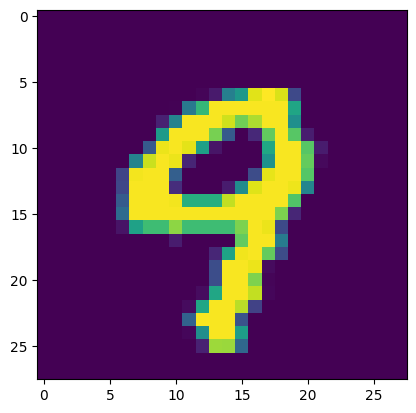

In [107]:
plt.imshow(X_sample.reshape(28,28))